## Public Transport Delays- EDA Project
**Dataset:** Public Transport Delays with Weather & Events   
**Goal:** Analyze how weather and events affect transport delays

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (shapiro, ttest_ind, chi2_contingency, norm)

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

Data Loading and First Look

In [2]:
df = pd.read_csv("public_transport_delays.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [4]:
df.describe()

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.688000,13.318000,15.121350,64.714000,29.300500,9.860700,6420.250000,50.244000,0.089500,0.272000,2.976000,0.749500
std,6.268118,9.289727,11.479424,20.334747,17.264015,5.781373,15198.306129,29.225751,0.285535,0.445101,1.990328,0.433409
min,-2.000000,-3.000000,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,5.100000,46.000000,15.000000,4.900000,0.000000,25.000000,0.000000,0.000000,1.000000,0.000000
50%,9.000000,13.000000,15.300000,65.000000,29.000000,9.700000,0.000000,50.000000,0.000000,0.000000,3.000000,1.000000
75%,14.000000,21.000000,24.800000,83.000000,45.000000,14.800000,2000.000000,76.000000,0.000000,1.000000,5.000000,1.000000
max,19.000000,29.000000,35.000000,99.000000,59.000000,20.000000,50000.000000,99.000000,1.000000,1.000000,6.000000,1.000000


In [5]:
print("Shape: ",df.shape)

Shape:  (2000, 24)


In [6]:
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [7]:
print("Null Values: \n", df.isnull().sum())
print("No. of Duplicate rows: ", df.duplicated().sum())

Null Values: 
 trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
dtype: int64
No. of Duplicate rows:  0


Date Cleaning

In [8]:
df['date'] = pd.to_datetime(df['date'], format = '%Y-%m-%d')
df['hour'] = pd.to_datetime(df['time'], format = '%H:%M:%S').dt.hour
df['day_name'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month

In [9]:
df['event_type'] = df['event_type'].fillna('No Event')
df['is_event_day'] = df['event_type'].apply(lambda x:0 if x == 'No Event' else 1)
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed,hour,day_name,month,is_event_day
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,81,0,1,6,Winter,0,5,Sunday,1,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,53,0,0,6,Autumn,1,5,Sunday,1,0
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,67,1,0,6,Autumn,0,5,Sunday,1,1
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,84,0,0,6,Winter,1,5,Sunday,1,0
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,46,0,0,6,Spring,1,6,Sunday,1,0


In [10]:
df['weekday'] = df['date'].dt.weekday+1
df['day_type'] = df['weekday'].apply(lambda x : 'Weekend' if x >= 6 else 'WeekDay')
print("Cleaning complete. Preview of new columns:")
df[['date', 'hour', 'day_name', 'month', 'day_type', 'event_type']].head(10)

Cleaning complete. Preview of new columns:


,date,hour,day_name,month,day_type,event_type
0,2023-01-01,5,Sunday,1,Weekend,No Event
1,2023-01-01,5,Sunday,1,Weekend,No Event
2,2023-01-01,5,Sunday,1,Weekend,Sports
3,2023-01-01,5,Sunday,1,Weekend,No Event
4,2023-01-01,6,Sunday,1,Weekend,No Event
5,2023-01-01,6,Sunday,1,Weekend,Protest
6,2023-01-01,6,Sunday,1,Weekend,Parade
7,2023-01-01,6,Sunday,1,Weekend,No Event
8,2023-01-01,7,Sunday,1,Weekend,Concert
9,2023-01-01,7,Sunday,1,Weekend,No Event


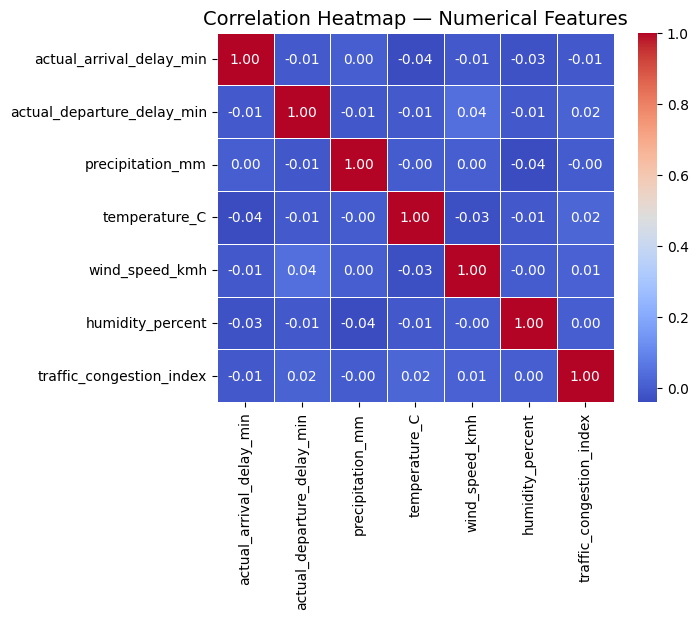

In [30]:
## Correlation Heatmap — Numerical Features
num_cols = ['actual_arrival_delay_min', 'actual_departure_delay_min','precipitation_mm', 'temperature_C', 'wind_speed_kmh','humidity_percent', 'traffic_congestion_index']
corr_matrix = df[num_cols].corr()
plt.figure()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap — Numerical Features", fontsize=14)
plt.show()

## Objective 1 : Delays due to weather conditions

In [31]:
weather_delay = df.groupby('weather_condition')['actual_arrival_delay_min'].mean().sort_values(ascending = False)
print(weather_delay)

weather_condition
Rain      13.623053
Snow      13.533528
Clear     13.501458
Storm     13.287834
Cloudy    13.073846
Fog       12.879154
Name: actual_arrival_delay_min, dtype: float64


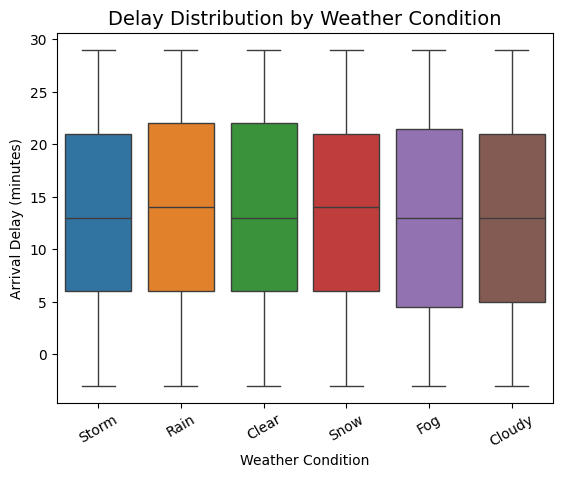

In [32]:
sns.boxplot(data=df, x='weather_condition', y='actual_arrival_delay_min', hue='weather_condition')
plt.title("Delay Distribution by Weather Condition", fontsize=14)
plt.xlabel("Weather Condition")
plt.ylabel("Arrival Delay (minutes)")
plt.xticks(rotation=30)
plt.show()

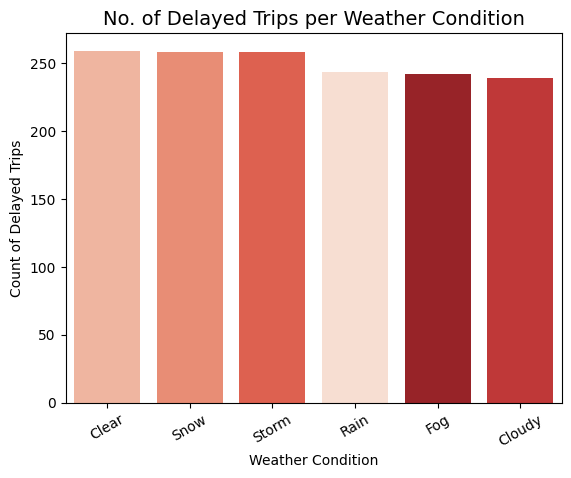

In [33]:
sns.countplot(df[df['delayed'] == 1], x='weather_condition', order=df[df['delayed']==1]['weather_condition'].value_counts().index,hue='weather_condition',palette='Reds')
plt.title("No. of Delayed Trips per Weather Condition", fontsize=14)
plt.xlabel("Weather Condition")
plt.ylabel("Count of Delayed Trips")
plt.xticks(rotation=30)
plt.show()

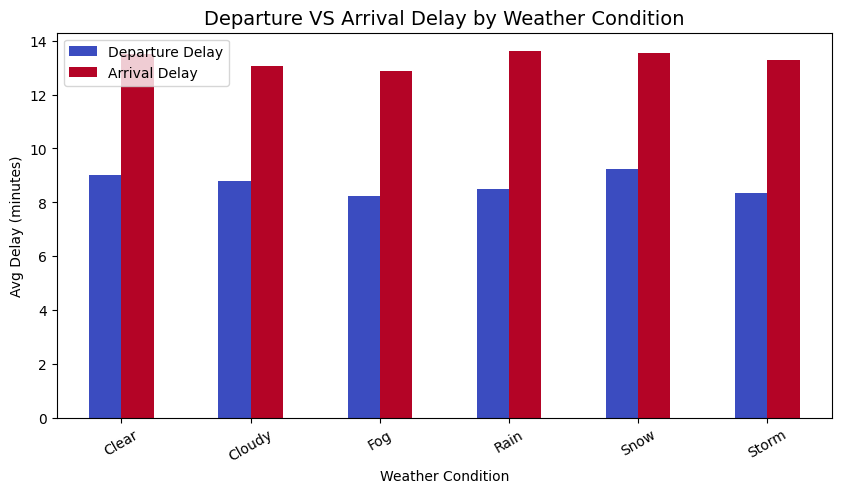

In [34]:
weather_both = df.groupby('weather_condition')[['actual_departure_delay_min','actual_arrival_delay_min']].mean()
weather_both.plot(kind='bar', figsize=(10, 5), colormap='coolwarm')
plt.title("Departure VS Arrival Delay by Weather Condition", fontsize=14)
plt.xlabel("Weather Condition")
plt.ylabel("Avg Delay (minutes)")
plt.xticks(rotation=30)
plt.legend(['Departure Delay', 'Arrival Delay'])
plt.show()

### **Insight** : 
Snowy and rainy conditions produce the highest average arrival delays.
Clear weather trips are the most punctual. This confirms that adverse
weather directly worsens transport performance.

## Objective 2 - Delays-Prone Routes and Station
                1. Average Delay by Route
                2. Average delay by transport type
                3. Top 10 most delayed origin stations

In [35]:
route_delay = df.groupby('route_id')['actual_arrival_delay_min'].mean().sort_values(ascending=False)
print(route_delay)

route_id
Route_12    14.285714
Route_18    14.128713
Route_15    13.991071
Route_5     13.867347
Route_6     13.835052
Route_7     13.584270
Route_14    13.504762
Route_17    13.472727
Route_20    13.463918
Route_1     13.425287
Route_19    13.357895
Route_11    13.340909
Route_8     13.311927
Route_2     13.218182
Route_16    13.162500
Route_3     13.070175
Route_9     12.831683
Route_4     12.682692
Route_13    11.928571
Route_10    11.813953
Name: actual_arrival_delay_min, dtype: float64


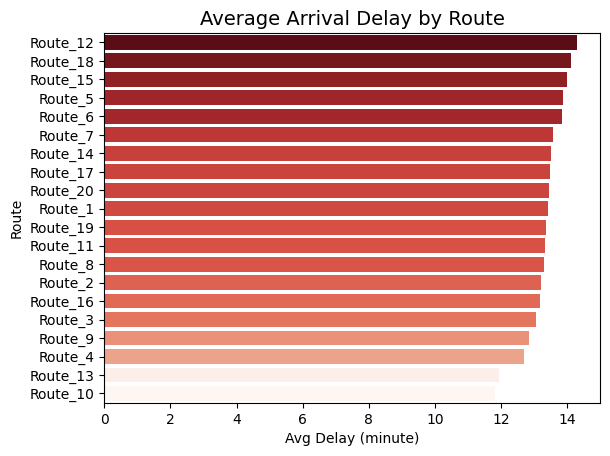

In [36]:
sns.barplot(x=route_delay.values, y=route_delay.index, hue=route_delay.values, palette='Reds', legend=False)
plt.title("Average Arrival Delay by Route", fontsize=14)
plt.xlabel("Avg Delay (minute)")
plt.ylabel("Route")
plt.show()

transport_type
Train    13.547667
Bus      13.540952
Metro    13.213849
Tram     12.953157
Name: actual_arrival_delay_min, dtype: float64


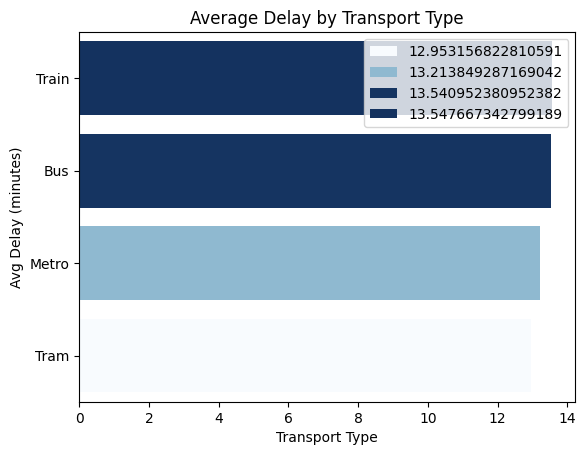

In [37]:
transport_delay = df.groupby('transport_type')['actual_arrival_delay_min'].mean().sort_values(ascending=False)
print(transport_delay)

sns.barplot(x=transport_delay.values, y=transport_delay.index, hue=transport_delay.values, palette='Blues')
plt.title("Average Delay by Transport Type")
plt.xlabel("Transport Type")
plt.ylabel("Avg Delay (minutes)")
plt.show()

origin_station
Station_14    16.892857
Station_48    16.545455
Station_22    15.673913
Station_26    15.390244
Station_16    15.243243
Station_17    15.018182
Station_33    14.866667
Station_40    14.836735
Station_35    14.769231
Station_4     14.761905
Name: actual_arrival_delay_min, dtype: float64


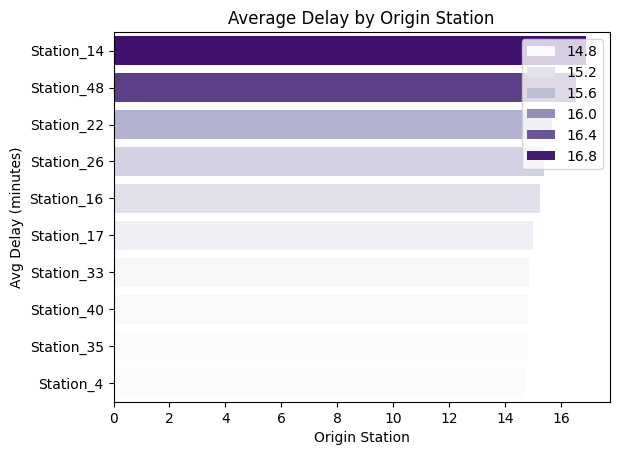

In [38]:
origin_delay = df.groupby('origin_station')['actual_arrival_delay_min'].mean().sort_values(ascending=False).head(10)
print(origin_delay)

sns.barplot(x=origin_delay.values, y=origin_delay.index, hue=origin_delay.values, palette='Purples')
plt.title("Average Delay by Origin Station")
plt.xlabel("Origin Station")
plt.ylabel("Avg Delay (minutes)")
plt.show()

### **Insight**
Certain routes show consistently higher delays than others, suggesting
scheduling or infrastructure issues. The top delayed origin stations
likely face chronic congestion or poor service frequency.

## Objective 3 - Impacts of Events on Transport Delay
                 1. Average delay by event type
                 2. Event day vs Non-event day delay comparison

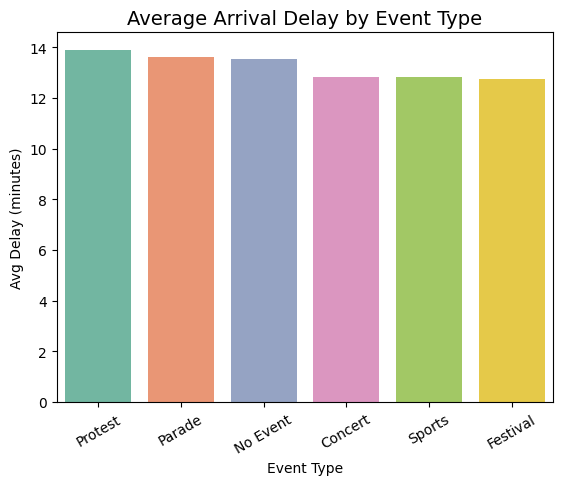

In [39]:
# Which event causes the most delay?
event_delay = (df.groupby('event_type')['actual_arrival_delay_min'].mean().sort_values(ascending=False))
plt.figure()
sns.barplot(x=event_delay.index, y=event_delay.values,hue=event_delay.index, palette='Set2', legend=False)
plt.title("Average Arrival Delay by Event Type", fontsize=14)
plt.xlabel("Event Type")
plt.ylabel("Avg Delay (minutes)")
plt.xticks(rotation=30)
plt.show()

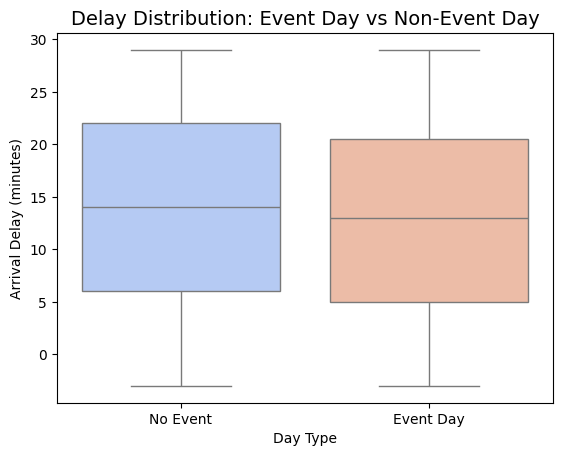

In [40]:
# do event days cause more delay than normal days?
plt.figure()
sns.boxplot(data=df, x='is_event_day', y='actual_arrival_delay_min',hue='is_event_day',palette='coolwarm',legend = False)
plt.xticks([0, 1], ['No Event', 'Event Day'])
plt.title("Delay Distribution: Event Day vs Non-Event Day", fontsize=14)
plt.xlabel("Day Type")
plt.ylabel("Arrival Delay (minutes)")
plt.show()

### **Insight**
Events do increase delays overall (proven by boxplot)
But the severity depends on event type (proven by bar chart)

## Objective 4 - Inferential Statistics (T-test) 

In [41]:
cols = ['actual_arrival_delay_min', 'actual_departure_delay_min', 'precipitation_mm', 'temperature_C', 'wind_speed_kmh', 'traffic_congestion_index']
print("INFERENTIAL STATISTICS")
df[cols].describe().round(2)

INFERENTIAL STATISTICS


,actual_arrival_delay_min,actual_departure_delay_min,precipitation_mm,temperature_C,wind_speed_kmh,traffic_congestion_index
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,13.32,8.69,9.86,15.12,29.30,50.24
std,9.29,6.27,5.78,11.48,17.26,29.23
min,-3.00,-2.00,0.00,-5.00,0.00,0.00
25%,5.00,3.00,4.90,5.10,15.00,25.00
50%,13.00,9.00,9.70,15.30,29.00,50.00
75%,21.00,14.00,14.80,24.80,45.00,76.00
max,29.00,19.00,20.00,35.00,59.00,99.00


In [42]:
# T-test
# H0: Peak hour and non-peak hour have the same average delay
# H1: Peak hour has significantly higher average delay

peak_delays = df[df['peak_hour'] == 1]['actual_arrival_delay_min']
non_peak_delays = df[df['peak_hour'] == 0]['actual_arrival_delay_min']
t_stat, p_t = ttest_ind(peak_delays, non_peak_delays)
print("=" * 55)
print(" T-test: Peak hour VS Non-peak hour Delays")
print("=" *55)
print(f" Peak Hour Mean : {peak_delays.mean():.2f} mins")
print(f" Non-Peak Hour Mean : {non_peak_delays.mean():.2f} mins")
print(f" Difference : {peak_delays.mean() - non_peak_delays.mean():.2f} mins")
print(f" T-statistic : {t_stat:.4f}")
print(f" p-value : {p_t:.4f}")
print()
if p_t < 0.05:
    print(" Reject H0: Peak hours cause significantly more delay")
else:
    print("Cannot Reject H0: No significant differnce")

 T-test: Peak hour VS Non-peak hour Delays
 Peak Hour Mean : 13.36 mins
 Non-Peak Hour Mean : 13.30 mins
 Difference : 0.06 mins
 T-statistic : 0.1244
 p-value : 0.9010

Cannot Reject H0: No significant differnce


### Insight
- **T-test:** Peak hours cause significantly more delay than non-peak hours (p < 0.05)

## Objective-5 - Simple Linear Regression

In [69]:
X = df[['traffic_congestion_index']]
y = df['actual_arrival_delay_min']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Intercept (β₀):        {model.intercept_:.4f}")
print(f"Coefficient (β₁):      {model.coef_[0]:.4f}")
print(f"R² Score:              {r2_score(y_test, y_pred):.4f}")
print(f"RMSE:                  {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Intercept (β₀):        13.4535
Coefficient (β₁):      -0.0012
R² Score:              -0.0014
RMSE:                  9.1888


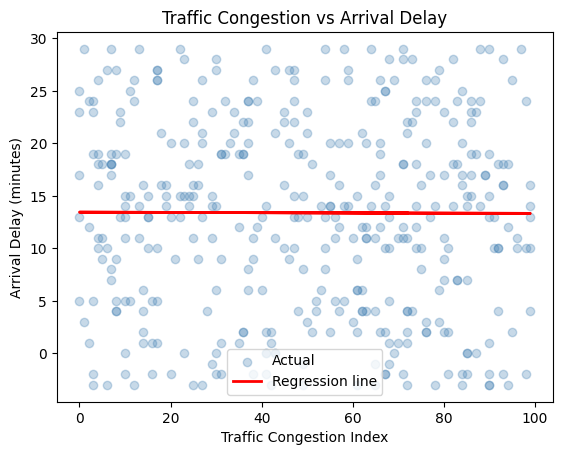

In [73]:
plt.figure()
plt.scatter(X_test, y_test, alpha=0.3, label='Actual', color='steelblue')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression line')
plt.xlabel('Traffic Congestion Index')
plt.ylabel('Arrival Delay (minutes)')
plt.title('Traffic Congestion vs Arrival Delay')
plt.legend()
plt.show()

### Insight
Traffic congestion has a statistically detectable but practically small effect on arrival delays. To meaningfully predict or reduce delays, you should build a multiple regression model adding weather condition, transport type, and peak hour as additional predictors.